<a href="https://colab.research.google.com/github/AJULUMEL/PCVK25_3F_07/blob/main/WEEK5_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA : DANDI AZRUL SYAHPUTRA

KELAS : TI 2C

NIM / NO.ABSEN : 2341720118 / 07

PERCOBAAN 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

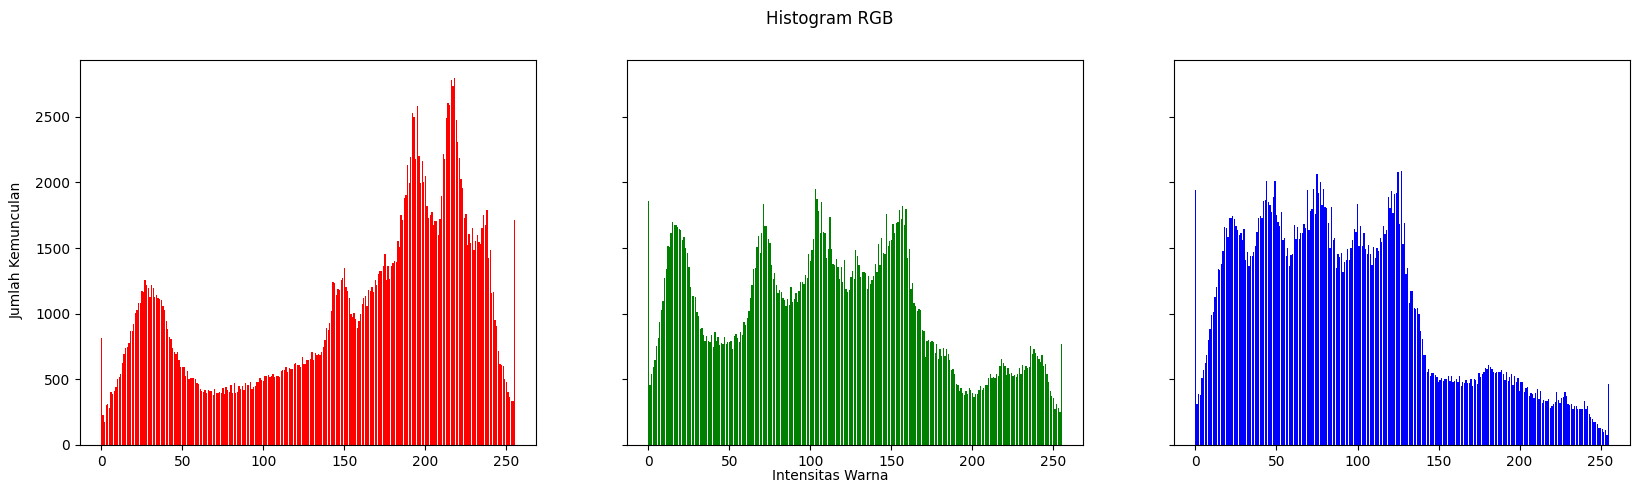

In [ ]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/Pertemuan 5/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

PRAKTIKUM D1

Apakah output histogram manual dan NumPy sama? True


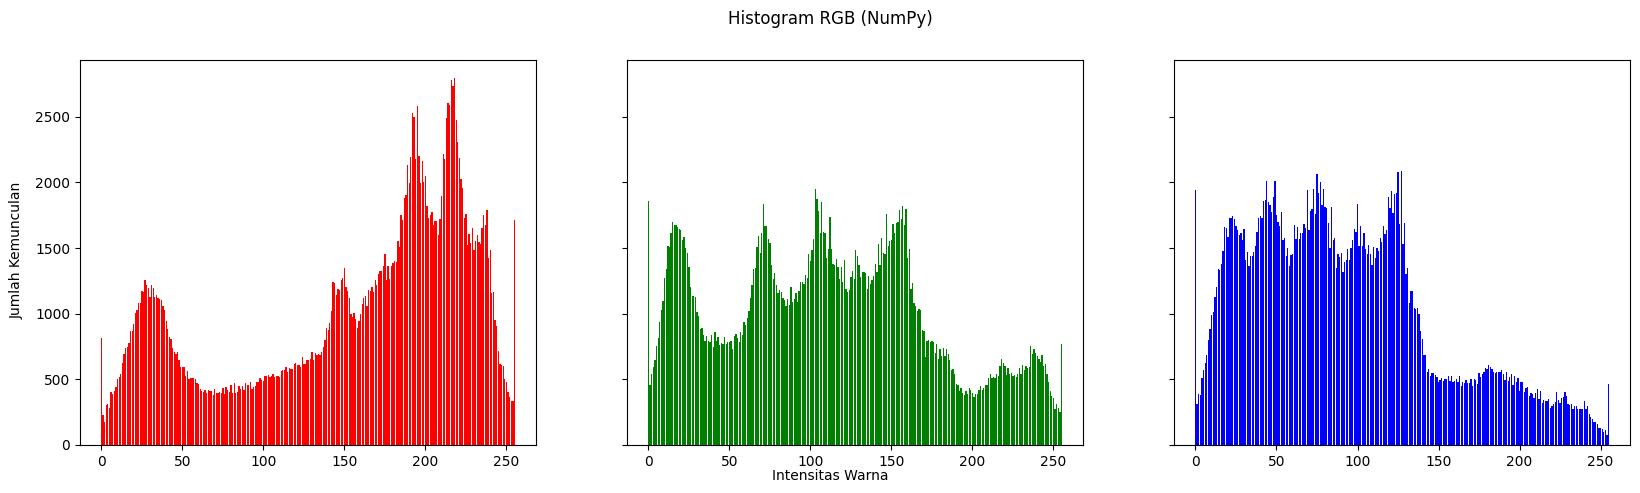

In [ ]:
# Membuat histogram image menggunakan NumPy
red_np, bins_red = np.histogram(img[:,:,0].flatten(), bins=256, range=[0, 256])
green_np, bins_green = np.histogram(img[:,:,1].flatten(), bins=256, range=[0, 256])
blue_np, bins_blue = np.histogram(img[:,:,2].flatten().flatten(), bins=256, range=[0, 256])

fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB (NumPy)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red_np, color='red')
axs[1].bar(names, green_np, color='green')
axs[2].bar(names, blue_np, color='blue')

# Membandingkan hasil
print("Apakah output histogram manual dan NumPy sama?", np.array_equal(red, red_np) and np.array_equal(green, green_np) and np.array_equal(blue, blue_np))

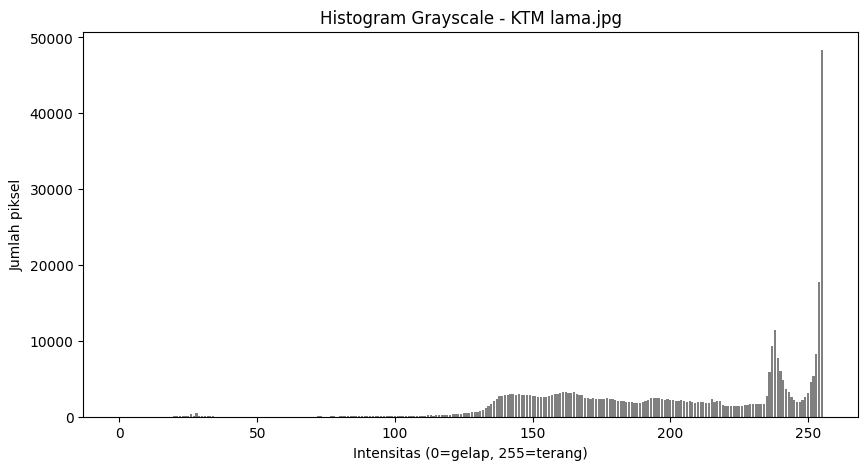

In [ ]:
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/Pertemuan 5/KTM lama.jpg')

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Histogram
hist, bins = np.histogram(gray.ravel(), bins=256, range=(0,256))

# Plot
plt.figure(figsize=(10,5))
plt.bar(bins[:-1], hist, color='gray')
plt.title("Histogram Grayscale - KTM lama.jpg")
plt.xlabel("Intensitas (0=gelap, 255=terang)")
plt.ylabel("Jumlah piksel")
plt.show()


D-2 PERCOBAAN HISTOGRAM EQUALIZATION

Buatlah histogram citra seperti output histogram equalization dan juga tampilan
gambar sebelum dan sesudah proses histogram equalization berikut berdasarkan
flowchart di bawah ini : (Gunakan gambar lena_lc.jpg)

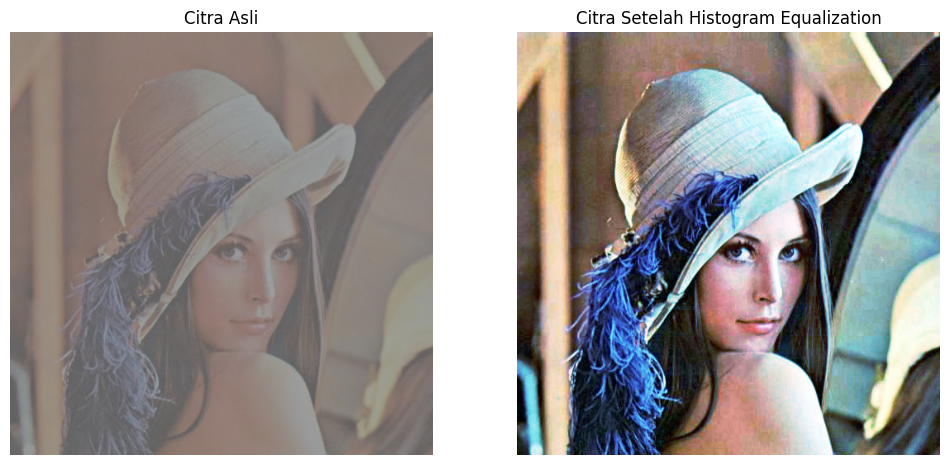

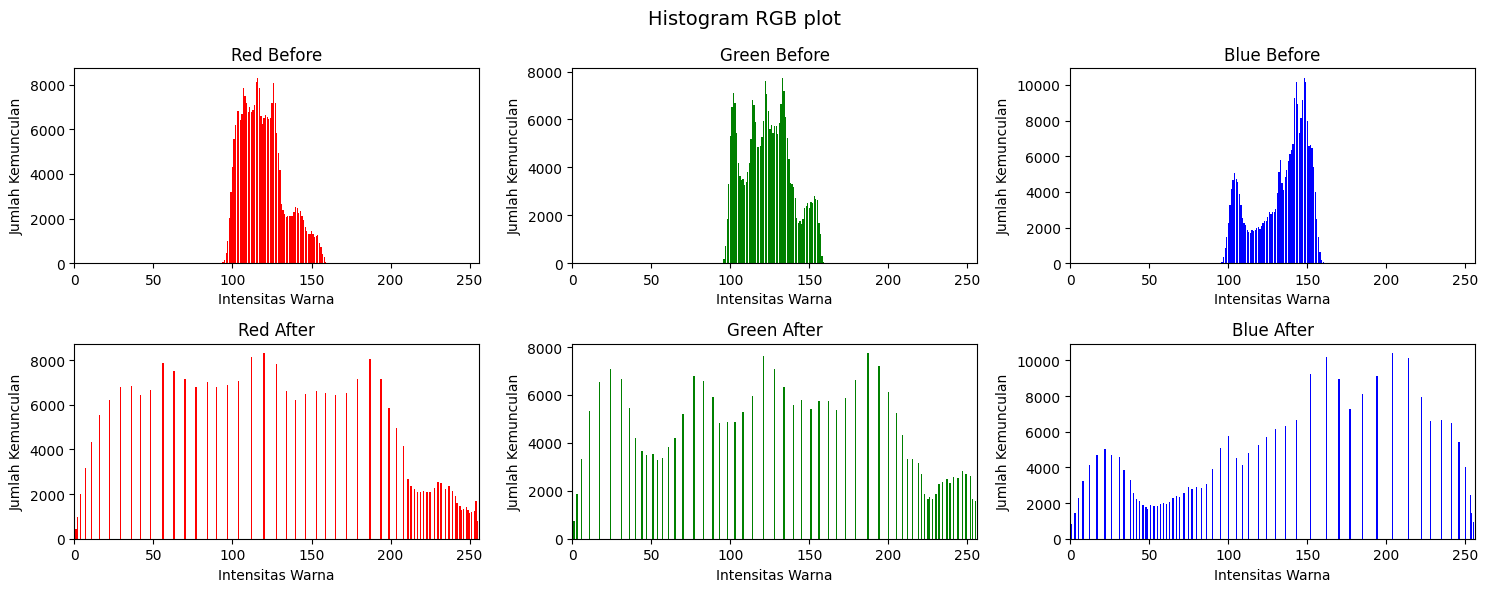

In [ ]:
# Baca gambar
img = cv.imread("/content/drive/MyDrive/Colab Notebooks/Pertemuan 5/lena_lc.jpg")

# --- Split channel ---
b, g, r = cv.split(img)

# --- Histogram Equalization tiap channel ---
b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)

# --- Gabungkan kembali ---
img_eq = cv.merge((b_eq, g_eq, r_eq))

# --- Tampilkan citra sebelum & sesudah ---
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(img_eq, cv.COLOR_BGR2RGB))
plt.title("Citra Setelah Histogram Equalization")
plt.axis("off")
plt.show()

# --- Histogram RGB sebelum & sesudah ---
colors = ('r','g','b')
channel_names = ('Red','Green','Blue')

fig, axs = plt.subplots(2,3, figsize=(15,6))
fig.suptitle("Histogram RGB plot", fontsize=14)

for i, col in enumerate(colors):
    # Before
    hist_before = cv.calcHist([img],[i],None,[256],[0,256])
    axs[0,i].bar(np.arange(256), hist_before.ravel(), color=col)
    axs[0,i].set_title(f"{channel_names[i]} Before")
    axs[0,i].set_xlim([0,256])
    axs[0,i].set_xlabel("Intensitas Warna")
    axs[0,i].set_ylabel("Jumlah Kemunculan")

    # After
    hist_after = cv.calcHist([img_eq],[i],None,[256],[0,256])
    axs[1,i].bar(np.arange(256), hist_after.ravel(), color=col)
    axs[1,i].set_title(f"{channel_names[i]} After")
    axs[1,i].set_xlim([0,256])
    axs[1,i].set_xlabel("Intensitas Warna")
    axs[1,i].set_ylabel("Jumlah Kemunculan")

plt.tight_layout()
plt.show()

Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada
potongan kode berikut ini.

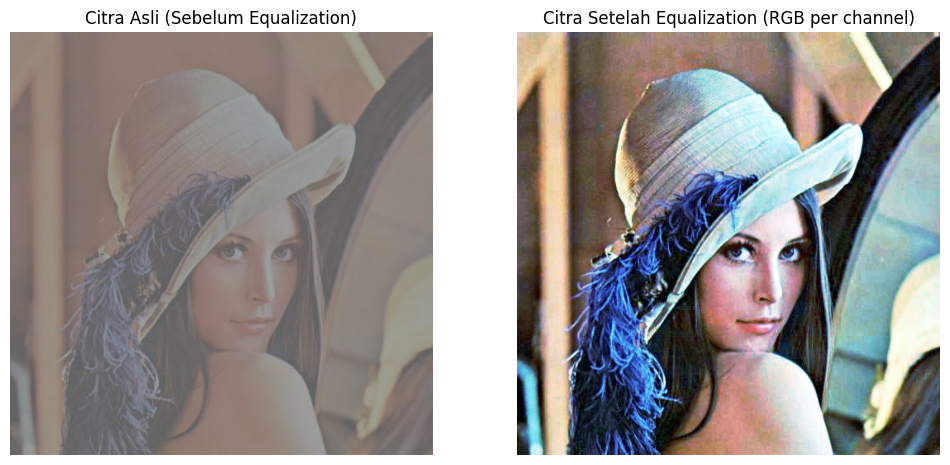

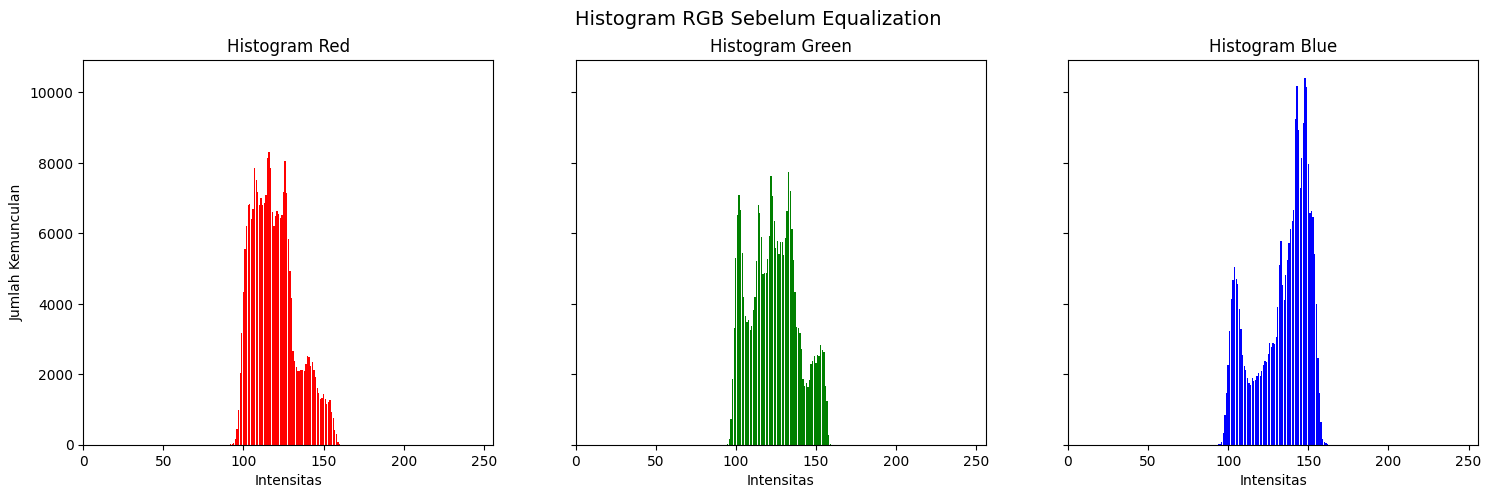

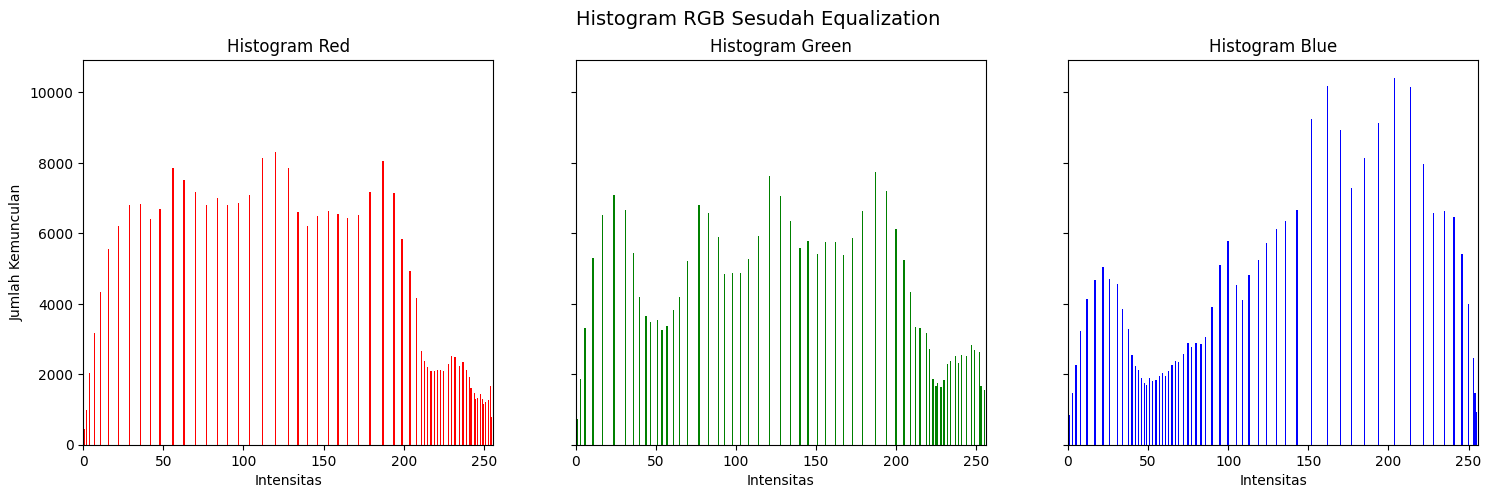

In [ ]:
# Baca gambar
img = cv.imread("/content/drive/MyDrive/Colab Notebooks/Pertemuan 5/lena_lc.jpg")

# Split ke R, G, B
B, G, R = cv.split(img)

# Histogram Equalization masing-masing channel
R_eq = cv.equalizeHist(R)
G_eq = cv.equalizeHist(G)
B_eq = cv.equalizeHist(B)

# Gabungkan kembali
img_eq = cv.merge((B_eq, G_eq, R_eq))

# Fungsi untuk menampilkan histogram per channel
def plot_histogram_subplot(img, title):
    channels = cv.split(img)
    colors = ('r', 'g', 'b')
    channel_names = ('Red', 'Green', 'Blue')
    fig, axs = plt.subplots(1, 3, figsize=(18,5), sharey=True)
    fig.suptitle(title, fontsize=14)

    for i, (ch, col) in enumerate(zip(channels, colors)):
        hist = cv.calcHist([ch],[0],None,[256],[0,256])
        axs[i].bar(np.arange(256), hist.ravel(), color=col)
        axs[i].set_title(f'Histogram {channel_names[i]}')
        axs[i].set_xlim([0,256])
        axs[i].set_xlabel("Intensitas")
        if i == 0:
            axs[i].set_ylabel("Jumlah Kemunculan")

    plt.show()

# Tampilkan gambar sebelum dan sesudah
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Citra Asli (Sebelum Equalization)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(img_eq, cv.COLOR_BGR2RGB))
plt.title("Citra Setelah Equalization (RGB per channel)")
plt.axis("off")
plt.show()

# Histogram sebelum dan sesudah
plot_histogram_subplot(img, "Histogram RGB Sebelum Equalization")
plot_histogram_subplot(img_eq, "Histogram RGB Sesudah Equalization")

PERTANYAAN PRAKTIKUM D2

PSNR Lena: 28.460093386445386


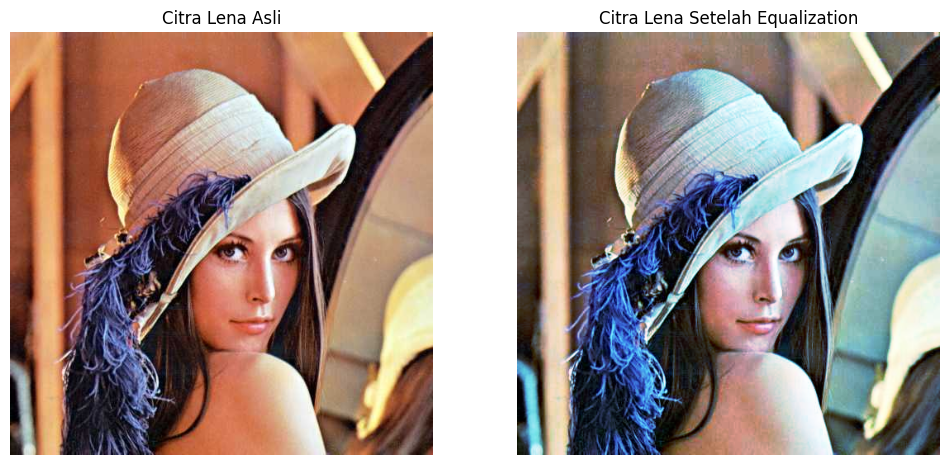

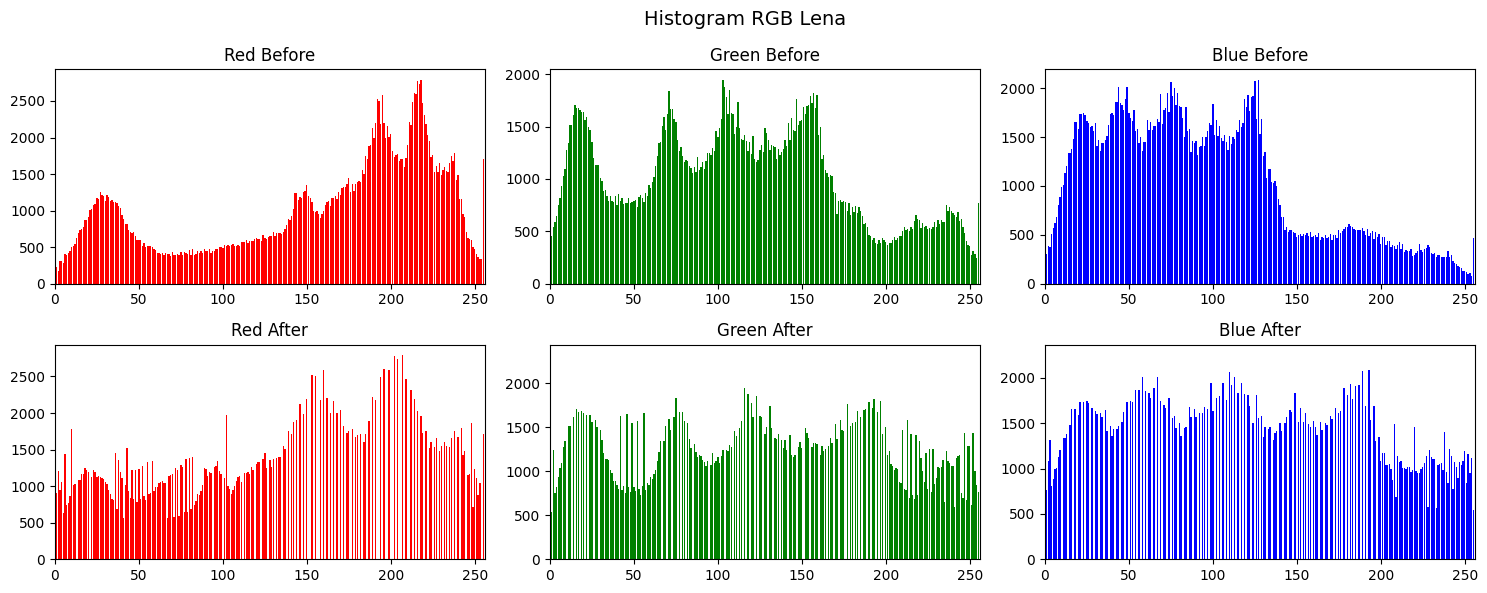

In [12]:
# =====================================================
# Fungsi bantu: hitung PSNR
# =====================================================
def psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    PIXEL_MAX = 255.0
    return 10 * np.log10((PIXEL_MAX ** 2) / mse)

# =====================================================
# 1. PERBANDINGAN CITRA LENA
# =====================================================
# Baca citra lena
img = cv.imread("/content/drive/MyDrive/Colab Notebooks/Pertemuan 5/lena.jpg")
b, g, r = cv.split(img)

# Equalization tiap channel
b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)

# Gabungkan
img_eq = cv.merge((b_eq, g_eq, r_eq))

# Hitung PSNR
psnr_value = psnr(img, img_eq)
print("PSNR Lena:", psnr_value)

# Tampilkan citra
plt.figure(figsize=(12,6))
plt.subplot(1,2,1), plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Citra Lena Asli"), plt.axis("off")
plt.subplot(1,2,2), plt.imshow(cv.cvtColor(img_eq, cv.COLOR_BGR2RGB))
plt.title("Citra Lena Setelah Equalization"), plt.axis("off")
plt.show()

# Histogram RGB Before vs After (2x3 layout)
colors = ('r','g','b')
channel_names = ('Red','Green','Blue')
channels_before = [r, g, b]
channels_after = [r_eq, g_eq, b_eq]

fig, axs = plt.subplots(2, 3, figsize=(15,6))
fig.suptitle("Histogram RGB Lena", fontsize=14)

for i, (chan_before, chan_after, col, name) in enumerate(zip(channels_before, channels_after, colors, channel_names)):
    hist_before = cv.calcHist([chan_before],[0],None,[256],[0,256])
    axs[0,i].bar(np.arange(256), hist_before.ravel(), color=col)
    axs[0,i].set_title(f"{name} Before")
    axs[0,i].set_xlim([0,256])

    hist_after = cv.calcHist([chan_after],[0],None,[256],[0,256])
    axs[1,i].bar(np.arange(256), hist_after.ravel(), color=col)
    axs[1,i].set_title(f"{name} After")
    axs[1,i].set_xlim([0,256])

plt.tight_layout()
plt.show()

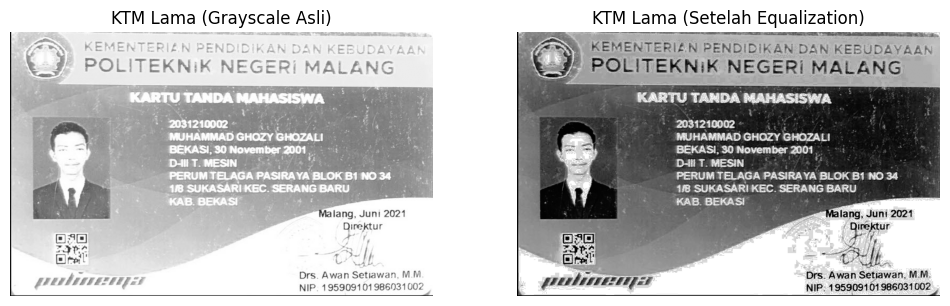

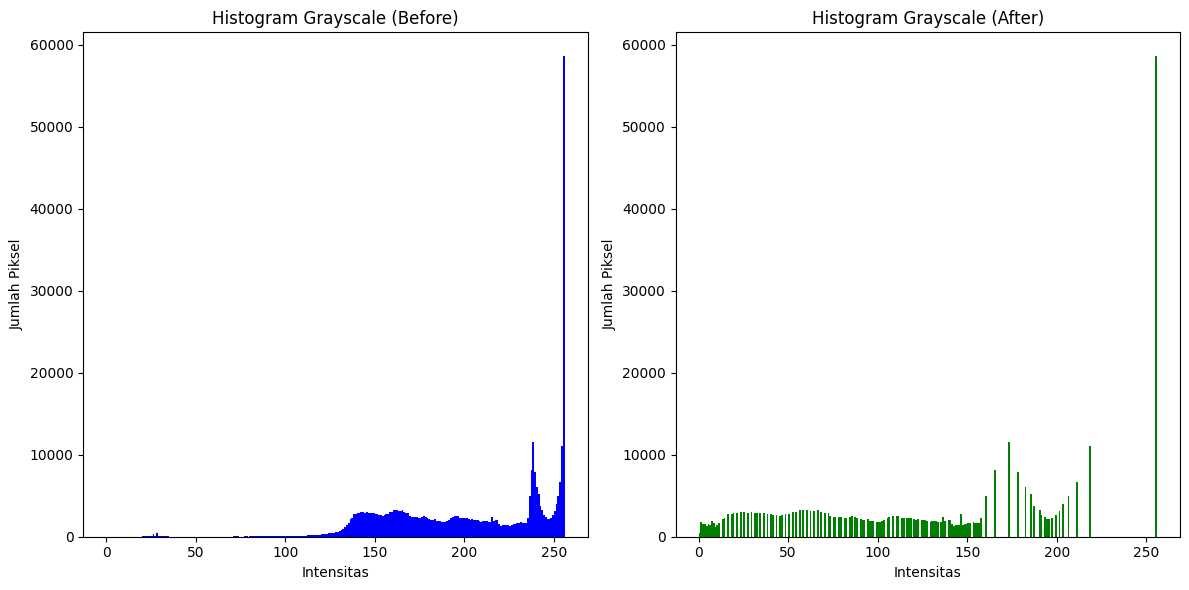

In [13]:
# =====================================================
# 2. CITRA KTM LAMA
# =====================================================
# Baca citra KTM Lama
ktm_gray = cv.imread("/content/drive/MyDrive/Colab Notebooks/Pertemuan 5/KTM lama.jpg", cv.IMREAD_GRAYSCALE)

# Equalization
ktm_eq = cv.equalizeHist(ktm_gray)

# Tampilkan citra sebelum & sesudah
plt.figure(figsize=(12,6))
plt.subplot(1,2,1), plt.imshow(ktm_gray, cmap='gray')
plt.title("KTM Lama (Grayscale Asli)"), plt.axis("off")
plt.subplot(1,2,2), plt.imshow(ktm_eq, cmap='gray')
plt.title("KTM Lama (Setelah Equalization)"), plt.axis("off")
plt.show()

# Histogram Grayscale Before vs After
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.hist(ktm_gray.ravel(), bins=256, range=(0,256), color='blue')
plt.title("Histogram Grayscale (Before)")
plt.xlabel("Intensitas"), plt.ylabel("Jumlah Piksel")

plt.subplot(1,2,2)
plt.hist(ktm_eq.ravel(), bins=256, range=(0,256), color='green')
plt.title("Histogram Grayscale (After)")
plt.xlabel("Intensitas"), plt.ylabel("Jumlah Piksel")

plt.tight_layout()
plt.show()

Nilai PSNR Lena = 28.46 dB menunjukkan ada perbedaan signifikan antara citra asli dan hasil equalization. Perubahan ini wajar karena histogram equalization memang mengubah distribusi intensitas. Secara visual, hasilnya positif: citra lebih terang, kontras lebih baik, dan detail lebih jelas.

Histogram equalization pada citra KTM Lama (grayscale) berhasil meningkatkan kualitas informasi visual. Detail wajah lebih jelas dan teks lebih terbaca dibanding citra asli. Meskipun ada efek samping berupa peningkatan kontras yang kadang membuat citra terlihat agak keras, hasil equalization tetap lebih bermanfaat dibanding citra sebelum pemrosesan.

D-3 TUGAS PRAKTIKUM DITHERING

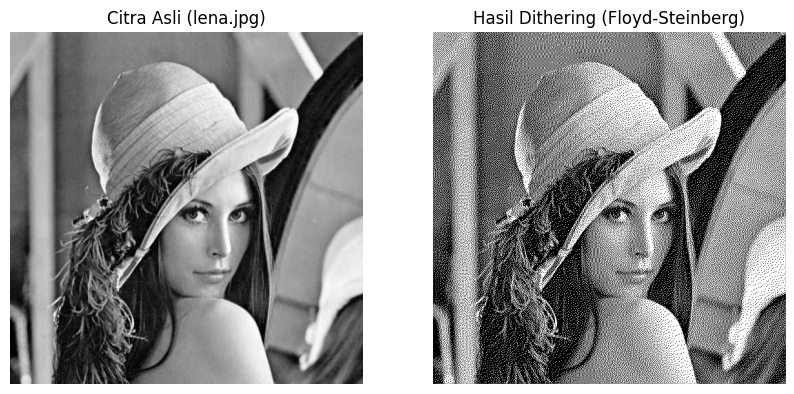

In [14]:
# Fungsi untuk Floyd-Steinberg Dithering
def floyd_steinberg_dithering(img):
    h, w = img.shape
    out = img.copy().astype(np.float32)

    for y in range(h - 1):
        for x in range(1, w - 1):
            old_pixel = out[y, x]
            new_pixel = 255 if old_pixel > 127 else 0
            out[y, x] = new_pixel
            error = old_pixel - new_pixel

            # Sebarkan error ke tetangga (kernel Floyd-Steinberg)
            out[y, x+1]   += error * 7/16
            out[y+1, x-1] += error * 3/16
            out[y+1, x]   += error * 5/16
            out[y+1, x+1] += error * 1/16

    # Pastikan nilai dalam rentang [0,255]
    out = np.clip(out, 0, 255)
    return out.astype(np.uint8)

img_lena = cv.imread("/content/drive/MyDrive/Colab Notebooks/Pertemuan 5/lena.jpg", cv.IMREAD_GRAYSCALE)
dither_lena = floyd_steinberg_dithering(img_lena)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_lena, cmap="gray")
plt.title("Citra Asli (lena.jpg)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(dither_lena, cmap="gray")
plt.title("Hasil Dithering (Floyd-Steinberg)")
plt.axis("off")
plt.show()

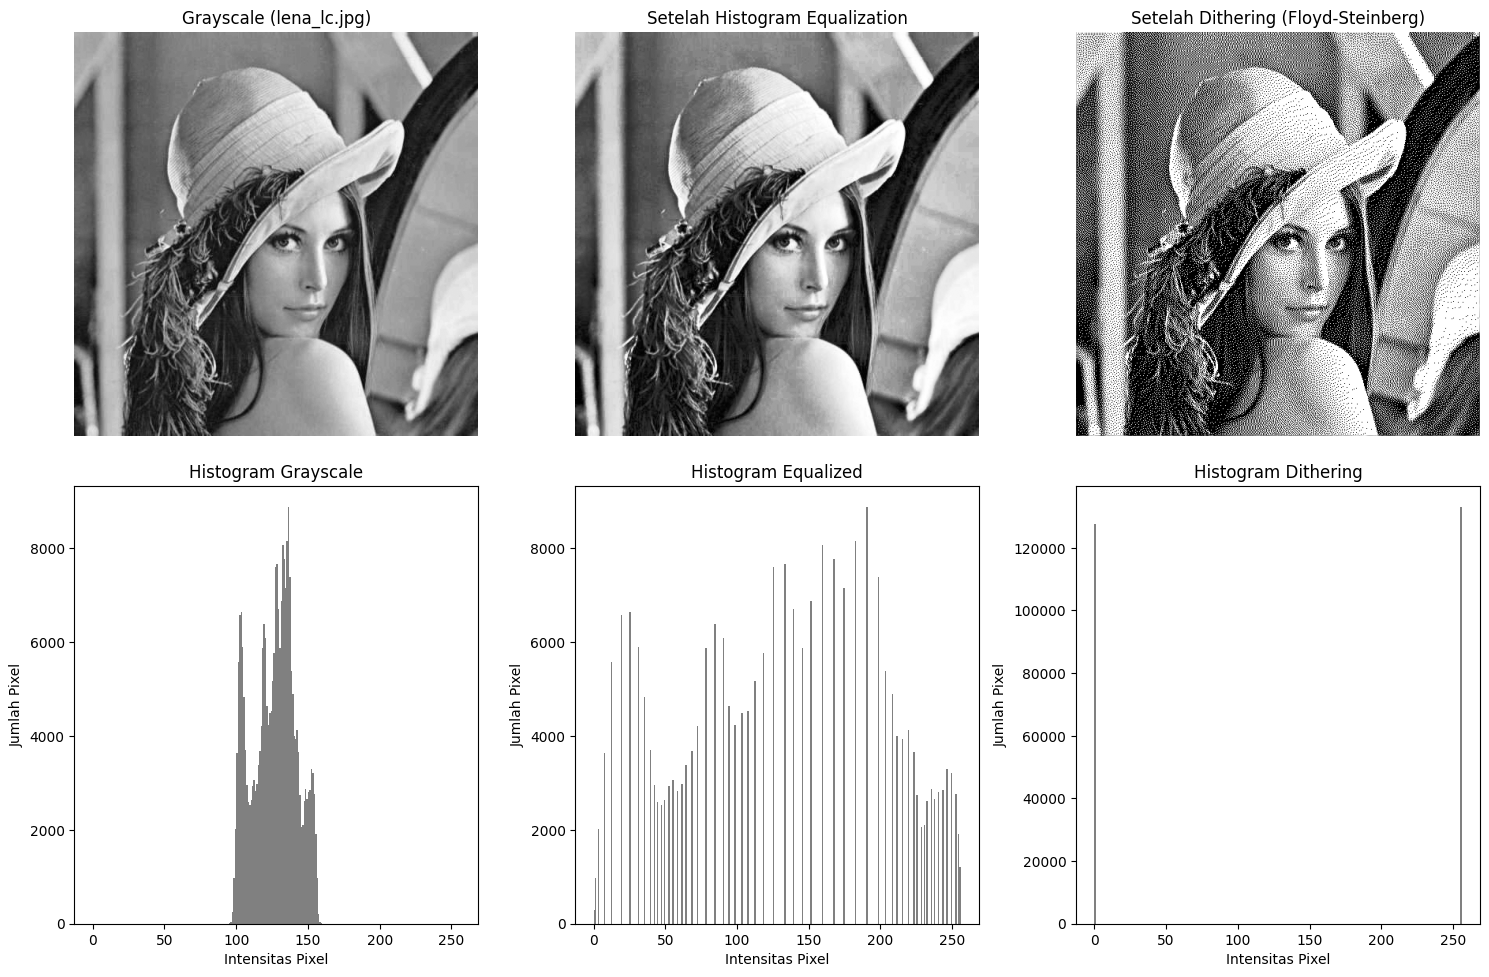

In [15]:
def floyd_steinberg_dithering(img):
    h, w = img.shape
    out = img.copy().astype(np.float32)
    for y in range(h - 1):
        for x in range(1, w - 1):
            old_pixel = out[y, x]
            new_pixel = 255 if old_pixel > 127 else 0
            out[y, x] = new_pixel
            error = old_pixel - new_pixel
            out[y, x+1]   += error * 7/16
            out[y+1, x-1] += error * 3/16
            out[y+1, x]   += error * 5/16
            out[y+1, x+1] += error * 1/16
    out = np.clip(out, 0, 255)
    return out.astype(np.uint8)

img_lc = cv.imread("/content/drive/MyDrive/Colab Notebooks/Pertemuan 5/lena_lc.jpg")
gray = cv.cvtColor(img_lc, cv.COLOR_BGR2GRAY)
equalized = cv.equalizeHist(gray)
dithered = floyd_steinberg_dithering(equalized)

plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale (lena_lc.jpg)")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(equalized, cmap="gray")
plt.title("Setelah Histogram Equalization")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(dithered, cmap="gray")
plt.title("Setelah Dithering (Floyd-Steinberg)")
plt.axis("off")

plt.subplot(2,3,4)
plt.hist(gray.ravel(), bins=256, range=(0,256), color="grey")
plt.title("Histogram Grayscale")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Jumlah Pixel")

plt.subplot(2,3,5)
plt.hist(equalized.ravel(), bins=256, range=(0,256), color="grey")
plt.title("Histogram Equalized")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Jumlah Pixel")

plt.subplot(2,3,6)
plt.hist(dithered.ravel(), bins=256, range=(0,256), color="grey")
plt.title("Histogram Dithering")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Jumlah Pixel")

plt.tight_layout()
plt.show()